# 86BB Gut State Mechanics: From Food to Microbiome to Health

This notebook builds the core simulation pipeline for the 86 Billion Butterflies installation, grounded in real diet–microbiome association data from the PREDICT 1 study (Asnicar et al., Nature Medicine 2021, n=1,098).

**Pipeline:**
1. **Species importance analysis** → determine which of the 176 species are diet-responsive
2. **Food-to-category mapping** → assign each of 84 foods a 20-D food group weight vector
3. **Category-to-species interpolation** → compute per-food microbiome profiles
4. **Health scoring** → composite metric combining species composition, dietary diversity, and centroid proximity
5. **Archetype diet synthesis** → 25+ diet archetypes from global food cultures
6. **3D visualization** → interactive PCA projections of the gut state landscape
7. **EMA simulation** → simulate food selection sequences and watch the gut state evolve
8. **Cluster analysis** → identify natural groupings and visualize cluster centroids

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from pathlib import Path

plt.style.use('dark_background')
sns.set_palette('Set2')
plt.rcParams.update({'figure.figsize': (14, 8), 'figure.dpi': 120, 'font.size': 10})

PLOTLY_DARK = 'plotly_dark'
OUT_DIR = Path('../outputs')
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
corr_matrix = pd.read_csv(OUT_DIR / 'predict1_food_species_correlations.csv', index_col=0)
q_matrix = pd.read_csv(OUT_DIR / 'predict1_food_species_qvalues.csv', index_col=0)

t9 = pd.read_excel(
    Path('../data/predict1_paper/supplementary/41591_2020_1183_MOESM10_ESM.xlsx'),
    sheet_name='Ranks', skiprows=3, engine='openpyxl'
)
t9.columns = ['species'] + list(t9.columns[1:])
t9 = t9[t9['species'].notna() & (t9['species'] != 'Category')].reset_index(drop=True)
t9['Final Rank'] = pd.to_numeric(t9['Final Rank'], errors='coerce')
t9 = t9.dropna(subset=['Final Rank']).set_index('species')

FOOD_GROUPS = list(corr_matrix.columns)
ALL_SPECIES = list(corr_matrix.index)
print(f'Loaded: {len(ALL_SPECIES)} species x {len(FOOD_GROUPS)} food groups')
print(f'Health rankings for {len(t9)} species')

Loaded: 176 species x 20 food groups
Health rankings for 176 species


---
## 1. Species Importance Analysis

Not all 176 species respond meaningfully to diet. We compute a composite importance score per species and let the distribution determine which species to keep.

In [3]:
importance = pd.DataFrame(index=ALL_SPECIES)
importance['max_abs_r'] = corr_matrix.abs().max(axis=1)
importance['n_significant'] = (q_matrix < 0.2).sum(axis=1)
importance['profile_variance'] = corr_matrix.var(axis=1)
importance['profile_range'] = corr_matrix.max(axis=1) - corr_matrix.min(axis=1)

importance['max_abs_r_norm'] = importance['max_abs_r'] / importance['max_abs_r'].max()
importance['n_sig_norm'] = importance['n_significant'] / importance['n_significant'].max()
importance['var_norm'] = importance['profile_variance'] / importance['profile_variance'].max()

importance['composite_score'] = (
    0.4 * importance['max_abs_r_norm'] +
    0.35 * importance['n_sig_norm'] +
    0.25 * importance['var_norm']
)
importance = importance.sort_values('composite_score', ascending=False)

print(f'Top 15 most diet-responsive species:')
print(importance[['max_abs_r', 'n_significant', 'composite_score']].head(15).to_string())

Top 15 most diet-responsive species:
                                 max_abs_r  n_significant  composite_score
Firmicutes_bacterium_CAG_94       0.157708             12         0.708477
Lawsonibacter_asaccharolyticus    0.380371              2         0.708333
Clostridium_leptum                0.207956              8         0.631367
Anaeromassilibacillus_sp_An250    0.164475             11         0.627846
Bifidobacterium_animalis          0.199390              8         0.619191
Agathobaculum_butyriciproducens   0.206795              8         0.612676
Ruthenibacterium_lactatiformans   0.180575              8         0.592316
Roseburia_hominis                 0.197078              8         0.562082
Clostridium_innocuum              0.137262              9         0.536201
Anaerostipes_hadrus               0.141566              7         0.493552
Clostridium_symbiosum             0.160137              7         0.479067
Clostridium_spiroforme            0.136690              7      

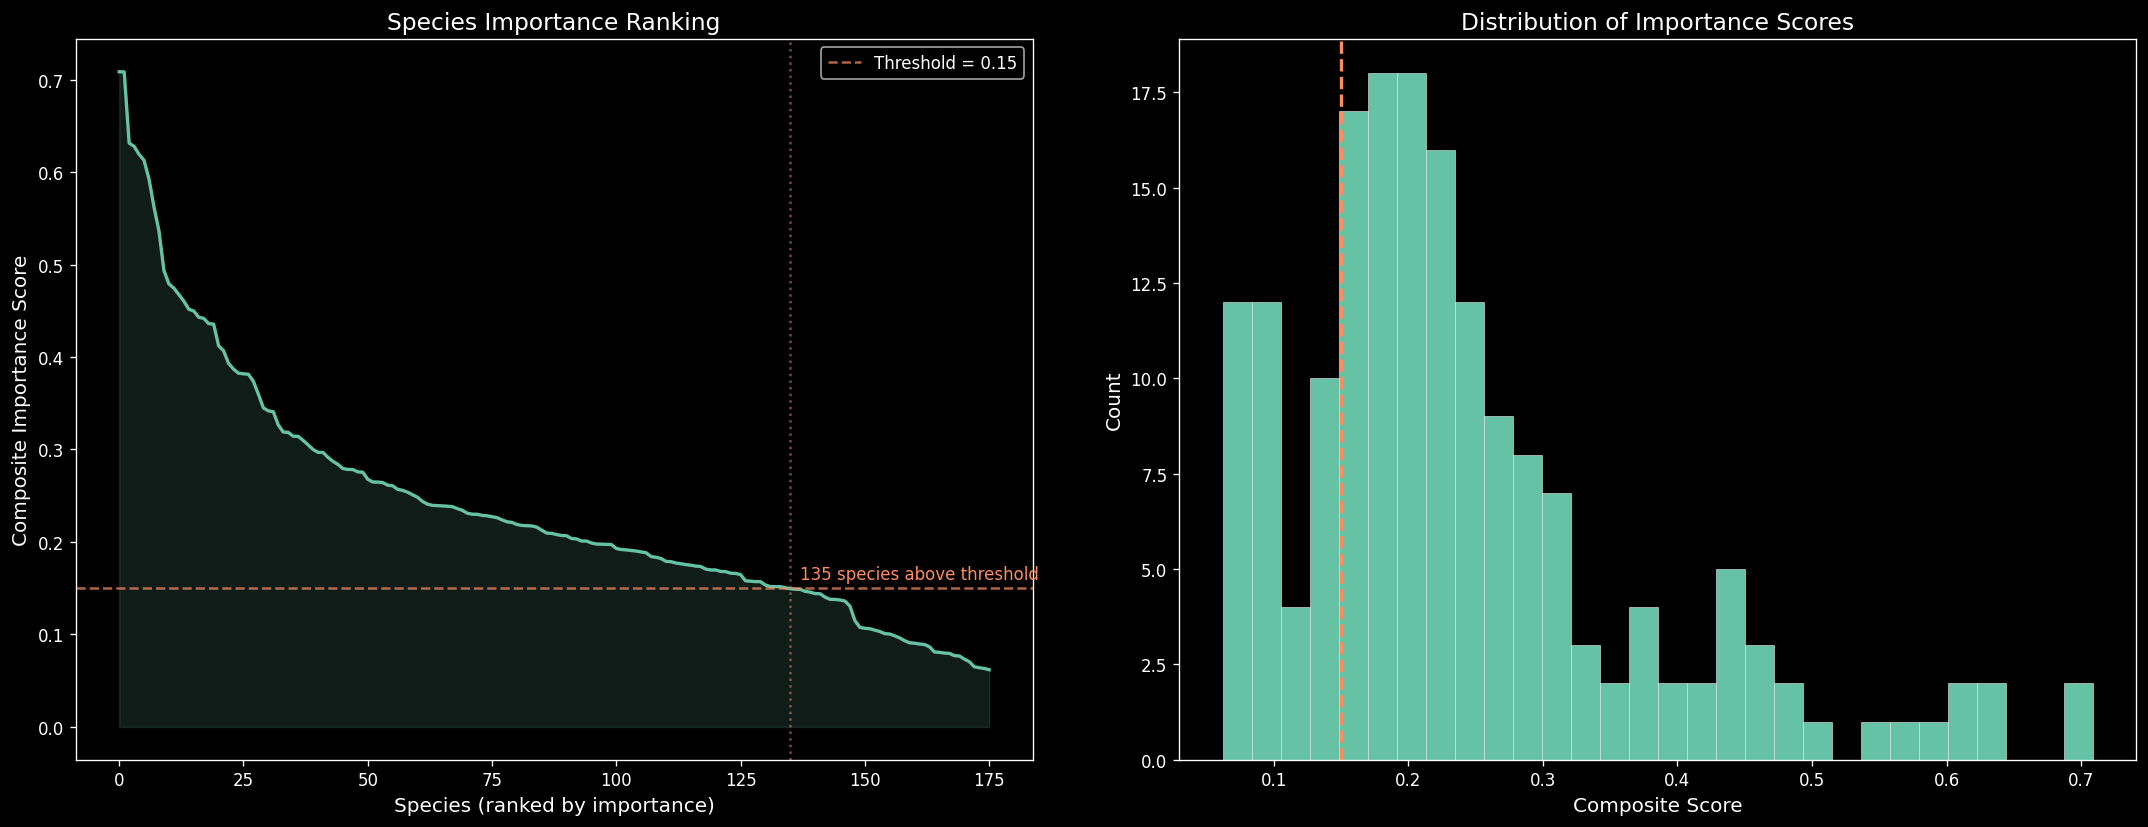


Species passing threshold (0.15): 135 of 176


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ax = axes[0]
scores = importance['composite_score'].values
ax.plot(range(len(scores)), scores, color='#66C2A5', linewidth=2)
ax.fill_between(range(len(scores)), scores, alpha=0.15, color='#66C2A5')
ax.set_xlabel('Species (ranked by importance)', fontsize=12)
ax.set_ylabel('Composite Importance Score', fontsize=12)
ax.set_title('Species Importance Ranking', fontsize=14)
ax.axhline(0.15, color='#FC8D62', linestyle='--', alpha=0.7, label='Threshold = 0.15')
n_above = (scores >= 0.15).sum()
ax.axvline(n_above, color='#FC8D62', linestyle=':', alpha=0.5)
ax.annotate(f'{n_above} species above threshold', xy=(n_above + 2, 0.16), fontsize=10, color='#FC8D62')
ax.legend()

ax = axes[1]
ax.hist(importance['composite_score'], bins=30, color='#66C2A5', edgecolor='white', linewidth=0.3)
ax.axvline(0.15, color='#FC8D62', linestyle='--', linewidth=2)
ax.set_xlabel('Composite Score', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Distribution of Importance Scores', fontsize=14)

plt.tight_layout()
plt.show()

THRESHOLD = 0.15
important_species = importance[importance['composite_score'] >= THRESHOLD].index.tolist()
print(f'\nSpecies passing threshold ({THRESHOLD}): {len(important_species)} of {len(ALL_SPECIES)}')

---
## 2. Food-to-Category Weight Vectors

Each food item gets a 20-D weight vector mapping it to PREDICT 1 food groups. Weights sum to 1. Multi-component foods (pizza, burger, etc.) get distributed weights across multiple groups.

In [5]:
FOOD_CATEGORY_MAP = {
    'yogurt': {'Dairy': 1.0}, 'kimchi': {'Vegetables': 0.7, 'Legumes': 0.3},
    'kombucha': {'Tea_coffee': 0.7, 'Sugar_sweetened_beverages': 0.3},
    'sauerkraut': {'Vegetables': 1.0}, 'miso_soup': {'Legumes': 0.7, 'Vegetables': 0.3},
    'tempeh': {'Legumes': 1.0}, 'natto': {'Legumes': 1.0}, 'pickles': {'Vegetables': 1.0},
    'banana': {'Fruits': 1.0}, 'blueberries': {'Fruits': 1.0}, 'apple': {'Fruits': 1.0},
    'pomegranate': {'Fruits': 1.0}, 'mango': {'Fruits': 1.0}, 'grapes': {'Fruits': 1.0},
    'watermelon': {'Fruits': 1.0}, 'orange': {'Fruits': 1.0}, 'strawberry': {'Fruits': 1.0},
    'pear': {'Fruits': 1.0}, 'lemon': {'Fruits': 1.0},
    'garlic': {'Vegetables': 1.0}, 'asparagus': {'Vegetables': 1.0},
    'sweet_potato': {'Vegetables': 0.6, 'Potatoes': 0.4}, 'broccoli': {'Vegetables': 1.0},
    'spinach': {'Vegetables': 1.0}, 'artichoke': {'Vegetables': 1.0},
    'carrot': {'Vegetables': 1.0}, 'corn': {'Vegetables': 0.6, 'Whole_grain': 0.4},
    'mushroom': {'Vegetables': 1.0}, 'beet': {'Vegetables': 1.0}, 'ginger': {'Vegetables': 1.0},
    'peas': {'Vegetables': 0.5, 'Legumes': 0.5},
    'avocado': {'Vegetables': 0.6, 'Vegetable_oils': 0.4}, 'salad': {'Vegetables': 1.0},
    'oatmeal': {'Whole_grain': 1.0}, 'sourdough': {'Whole_grain': 0.6, 'Refined_grains': 0.4},
    'brown_rice': {'Whole_grain': 1.0}, 'quinoa': {'Whole_grain': 1.0},
    'barley': {'Whole_grain': 1.0}, 'rice': {'Refined_grains': 0.7, 'Whole_grain': 0.3},
    'grilled_chicken': {'Meat': 1.0}, 'salmon': {'Fish_seafood': 1.0}, 'eggs': {'Egg': 1.0},
    'tofu': {'Legumes': 1.0}, 'steak': {'Meat': 1.0}, 'shrimp': {'Fish_seafood': 1.0},
    'kefir': {'Dairy': 1.0}, 'aged_cheese': {'Dairy': 1.0}, 'cottage_cheese': {'Dairy': 1.0},
    'butter': {'Animal_fats': 0.7, 'Dairy': 0.3}, 'whey_protein': {'Dairy': 1.0},
    'green_tea': {'Tea_coffee': 1.0}, 'red_wine': {'Alcohol': 1.0}, 'coffee': {'Tea_coffee': 1.0},
    'bone_broth': {'Meat': 0.5, 'Misc_animal_foods': 0.5}, 'soda': {'Sugar_sweetened_beverages': 1.0},
    'bubble_tea': {'Sugar_sweetened_beverages': 0.6, 'Tea_coffee': 0.3, 'Dairy': 0.1},
    'smoothie': {'Fruits': 0.6, 'Fruit_juices': 0.3, 'Dairy': 0.1},
    'beer': {'Alcohol': 0.8, 'Whole_grain': 0.2}, 'energy_drink': {'Sugar_sweetened_beverages': 1.0},
    'dark_chocolate': {'Sweets_desserts': 0.7, 'Nuts': 0.3}, 'candy_bar': {'Sweets_desserts': 1.0},
    'honey': {'Sweets_desserts': 1.0},
    'ice_cream': {'Sweets_desserts': 0.6, 'Dairy': 0.4},
    'pastry': {'Sweets_desserts': 0.5, 'Refined_grains': 0.3, 'Animal_fats': 0.2},
    'donut': {'Sweets_desserts': 0.5, 'Refined_grains': 0.3, 'Animal_fats': 0.2},
    'cake': {'Sweets_desserts': 0.5, 'Refined_grains': 0.3, 'Dairy': 0.2},
    'cookie': {'Sweets_desserts': 0.5, 'Refined_grains': 0.3, 'Animal_fats': 0.2},
    'black_beans': {'Legumes': 1.0}, 'lentils': {'Legumes': 1.0}, 'chickpeas': {'Legumes': 1.0},
    'edamame': {'Legumes': 1.0}, 'peanuts': {'Nuts': 0.7, 'Legumes': 0.3},
    'almonds': {'Nuts': 1.0}, 'walnuts': {'Nuts': 1.0},
    'flaxseed': {'Nuts': 0.7, 'Whole_grain': 0.3},
    'chia_seeds': {'Nuts': 0.7, 'Whole_grain': 0.3}, 'sunflower_seeds': {'Nuts': 1.0},
    'pizza': {'Refined_grains': 0.35, 'Dairy': 0.25, 'Meat': 0.2, 'Vegetables': 0.1, 'Vegetable_oils': 0.1},
    'burger': {'Meat': 0.4, 'Refined_grains': 0.3, 'Vegetables': 0.1, 'Animal_fats': 0.1, 'Sweets_desserts': 0.1},
    'fries': {'Potatoes': 0.5, 'Vegetable_oils': 0.3, 'Refined_grains': 0.2},
    'hot_dog': {'Meat': 0.5, 'Refined_grains': 0.3, 'Animal_fats': 0.2},
    'nachos': {'Refined_grains': 0.4, 'Dairy': 0.2, 'Vegetables': 0.2, 'Vegetable_oils': 0.2},
    'chips': {'Potatoes': 0.4, 'Vegetable_oils': 0.4, 'Refined_grains': 0.2},
    'ramen': {'Refined_grains': 0.4, 'Meat': 0.2, 'Vegetables': 0.2, 'Egg': 0.1, 'Vegetable_oils': 0.1},
    'popcorn': {'Whole_grain': 0.5, 'Vegetable_oils': 0.3, 'Animal_fats': 0.2},
    'sushi': {'Fish_seafood': 0.4, 'Refined_grains': 0.4, 'Vegetables': 0.2},
    'falafel': {'Legumes': 0.6, 'Vegetable_oils': 0.2, 'Vegetables': 0.2},
    'curry': {'Vegetables': 0.4, 'Vegetable_oils': 0.2, 'Legumes': 0.2, 'Meat': 0.2},
    'tacos': {'Meat': 0.3, 'Refined_grains': 0.3, 'Vegetables': 0.2, 'Dairy': 0.1, 'Legumes': 0.1},
    'pad_thai': {'Refined_grains': 0.3, 'Vegetables': 0.2, 'Nuts': 0.15, 'Egg': 0.15, 'Fish_seafood': 0.1, 'Vegetable_oils': 0.1},
    'dumpling': {'Refined_grains': 0.4, 'Meat': 0.3, 'Vegetables': 0.2, 'Vegetable_oils': 0.1},
    'granola_bar': {'Whole_grain': 0.3, 'Nuts': 0.3, 'Sweets_desserts': 0.3, 'Fruits': 0.1},
    'trail_mix': {'Nuts': 0.5, 'Fruits': 0.3, 'Sweets_desserts': 0.2},
    'pretzel': {'Refined_grains': 1.0},
}

weight_matrix = pd.DataFrame(0.0, index=list(FOOD_CATEGORY_MAP.keys()), columns=FOOD_GROUPS)
for food_id, groups in FOOD_CATEGORY_MAP.items():
    for group, weight in groups.items():
        weight_matrix.loc[food_id, group] = weight

print(f'Food items mapped: {len(weight_matrix)}')
print(f'All weights sum to 1: {(weight_matrix.sum(axis=1).round(6) == 1.0).all()}')

Food items mapped: 94
All weights sum to 1: True


---
## 3. Food → Species Profile Interpolation

Each food's microbiome profile = weighted sum of its food group correlations: $\text{profile}_i = \sum_g w_{i,g} \cdot \rho_g$

In [6]:
corr_np = corr_matrix.loc[important_species].values.T
food_species_profiles = weight_matrix.values @ corr_np
food_profiles_df = pd.DataFrame(food_species_profiles, index=weight_matrix.index, columns=important_species)
print(f'Food profiles: {food_profiles_df.shape}')

Food profiles: (94, 135)


---
## 4. Health Scoring

### Why a simple linear health score is misleading

Table 9 ranks species by their correlation with cardiometabolic blood markers (blood lipids, inflammation, glucose control, visceral fat). Using a simple dot product of the gut state with this health direction gives a **species composition score** — it captures *what* species you have.

But this score has blind spots:

- **Alcohol scores positive** because moderate drinkers in the PREDICT 1 cohort happened to have favorable microbiome profiles. This likely reflects *lifestyle confounding*: moderate drinkers also tend to eat diverse, Mediterranean-style diets. The microbiome association is real, but it's not causal — the correlation partly reflects overall diet quality, not the alcohol itself.
- **Meat scores very negative** because `Meat` as a food group includes everything from prosciutto to grilled chicken. Processed/red meat strongly associates with *Clostridium* species that correlate with poor cardiometabolic markers. A grilled chicken breast is healthier than the group average, but gets the same profile.
- **An all-beer diet scores as "healthy"** under the linear metric, which is clearly wrong. The score doesn't capture that dietary *monotony* itself degrades gut health.

### Composite health score

The PREDICT 1 paper found that **microbial diversity** (species richness and Shannon index) was one of the strongest correlates of health — more so than any individual species. BMI, visceral fat, and liver fat were all inversely correlated with diversity.

Our composite score combines three signals:
1. **Species composition** (40%): dot product with health direction vector — captures what species the gut state contains
2. **Dietary diversity** (35%): Shannon entropy of recent food group selections — captures the breadth of dietary input
3. **Centroid proximity** (25%): distance from a healthy reference profile — captures how "normal" vs extreme the gut state is

In [7]:
health_ranks = t9.loc[t9.index.intersection(important_species), 'Final Rank']
max_rank, min_rank = health_ranks.max(), health_ranks.min()
health_direction = 1.0 - 2.0 * (health_ranks - min_rank) / (max_rank - min_rank)
health_direction = health_direction.reindex(important_species).fillna(0)

def make_diet(weights_dict):
    v = np.zeros(len(FOOD_GROUPS))
    for g, w in weights_dict.items():
        v[FOOD_GROUPS.index(g)] = w
    return v / v.sum()

healthy_centroid = make_diet({
    'Vegetables': 3, 'Fruits': 2, 'Fish_seafood': 2, 'Nuts': 2,
    'Whole_grain': 2, 'Vegetable_oils': 2, 'Legumes': 1.5, 'Alcohol': 0.5,
    'Dairy': 1, 'Tea_coffee': 1
}) @ corr_np

# Compute reference scores for calibration
junk_centroid = make_diet({
    'Sugar_sweetened_beverages': 3, 'Sweets_desserts': 3, 'Refined_grains': 3,
    'Potatoes': 2, 'Animal_fats': 2, 'Meat': 2,
}) @ corr_np

healthy_linear = float(healthy_centroid @ health_direction.values)
junk_linear = float(junk_centroid @ health_direction.values)
linear_range = healthy_linear - junk_linear
linear_mid = (healthy_linear + junk_linear) / 2

centroid_scale = np.linalg.norm(healthy_centroid - junk_centroid)

def compute_health(gut_state, diet_history_groups, health_dir=health_direction.values,
                   centroid=healthy_centroid):
    # 1. Species composition: normalized so healthy_centroid ~ +1, junk_centroid ~ -1
    linear = float(gut_state @ health_dir)
    linear_norm = np.clip((linear - linear_mid) / (linear_range / 2), -1, 1)

    # 2. Dietary diversity: Shannon entropy of recent food group history
    #    This is a PENALTY for monotony, not a reward for random eating
    #    Map: 1.0 (max diverse) -> 0 penalty, 0.0 (mono) -> -0.5 penalty
    if len(diet_history_groups) > 0:
        counts = np.zeros(len(FOOD_GROUPS))
        for fg in diet_history_groups:
            counts[FOOD_GROUPS.index(fg)] += 1
        p = counts / counts.sum()
        p = p[p > 0]
        entropy = -np.sum(p * np.log(p))
        diversity_ratio = entropy / np.log(len(FOOD_GROUPS))
    else:
        diversity_ratio = 0.0
    diversity_penalty = -0.5 * (1.0 - diversity_ratio) ** 2

    # 3. Proximity to healthy centroid
    dist = np.linalg.norm(gut_state - centroid)
    proximity = np.clip(1.0 - dist / centroid_scale, -1, 1)

    # Composite: composition-dominant, diversity penalizes monotony, proximity is secondary
    composite = 0.6 * linear_norm + 0.15 * diversity_penalty + 0.25 * proximity
    return composite, linear_norm, diversity_penalty, proximity

print('Health scoring calibrated:')
print(f'  Healthy centroid linear: {healthy_linear:+.4f}')
print(f'  Junk centroid linear:    {junk_linear:+.4f}')
print(f'  Linear range:            {linear_range:.4f}')
print(f'  Centroid distance:       {centroid_scale:.4f}')


Health scoring calibrated:
  Healthy centroid linear: +2.4422
  Junk centroid linear:    -1.6938
  Linear range:            4.1360
  Centroid distance:       0.8255


In [8]:
def simulate_mono_diet(food_id, n_taps=100, alpha=0.08):
    gut = np.zeros(len(important_species))
    profile = food_profiles_df.loc[food_id].values
    groups = []
    for fg, w in FOOD_CATEGORY_MAP[food_id].items():
        groups.append(fg)
    diet_history = []
    for _ in range(n_taps):
        gut = (1 - alpha) * gut + alpha * profile
        diet_history.extend(groups)
    return gut, diet_history

test_foods = ['almonds', 'beer', 'soda', 'broccoli', 'steak', 'grilled_chicken',
              'red_wine', 'dark_chocolate', 'salmon', 'donut']

print(f'{"Food":20s} | {"Composite":>10s} | {"Composition":>12s} | {"Diversity":>10s} | {"Proximity":>10s}')
print('-' * 75)
results = []
for food in test_foods:
    gut, hist = simulate_mono_diet(food)
    comp, lin, div, prox = compute_health(gut, hist)
    results.append((food, comp, lin, div, prox))

results.sort(key=lambda x: x[1], reverse=True)
for food, comp, lin, div, prox in results:
    print(f'  {food:18s} | {comp:+10.4f} | {lin:+12.4f} | {div:10.4f} | {prox:10.4f}')

print()
print('Note: mono-diets are penalized by LOW dietary diversity (~0.0 for single-group foods).')
print('An all-beer diet now scores MUCH lower than a diverse diet containing beer.')

Food                 |  Composite |  Composition |  Diversity |  Proximity
---------------------------------------------------------------------------
  broccoli           |    +0.6739 |      +1.0000 |    -0.5000 |     0.5955
  almonds            |    +0.5925 |      +1.0000 |    -0.5000 |     0.2701
  salmon             |    +0.2913 |      +0.4170 |    -0.5000 |     0.4643
  beer               |    +0.1764 |      +0.2255 |    -0.2954 |     0.3415
  dark_chocolate     |    +0.0761 |      +0.0521 |    -0.2954 |     0.3565
  red_wine           |    -0.0329 |      +0.0157 |    -0.5000 |     0.1305
  donut              |    -0.3797 |      -0.6248 |    -0.2005 |     0.1012
  soda               |    -0.7397 |      -1.0000 |    -0.5000 |    -0.2587
  steak              |    -0.7624 |      -1.0000 |    -0.5000 |    -0.3496
  grilled_chicken    |    -0.7624 |      -1.0000 |    -0.5000 |    -0.3496

Note: mono-diets are penalized by LOW dietary diversity (~0.0 for single-group foods).
An all-beer

---
## 5. Archetype Diet Synthesis

We define 25+ dietary archetypes spanning global food cultures, then generate a cloud of gut profiles by adding noise and blending between archetypes.

In [9]:
ARCHETYPES = {
    # Classic patterns
    'Mediterranean':     make_diet({'Vegetables': 3, 'Fruits': 2, 'Fish_seafood': 2, 'Nuts': 2, 'Whole_grain': 2, 'Vegetable_oils': 2, 'Legumes': 1.5, 'Alcohol': 1}),
    'Western processed':  make_diet({'Refined_grains': 3, 'Meat': 3, 'Sweets_desserts': 2.5, 'Sugar_sweetened_beverages': 2, 'Animal_fats': 2, 'Potatoes': 1.5, 'Dairy': 1}),
    'Plant-based':       make_diet({'Vegetables': 4, 'Fruits': 3, 'Legumes': 3, 'Whole_grain': 3, 'Nuts': 2, 'Vegetable_oils': 1}),
    'Balanced':          make_diet({g: 1 for g in FOOD_GROUPS}),
    'Carnivore':         make_diet({'Meat': 5, 'Animal_fats': 3, 'Egg': 2, 'Fish_seafood': 1, 'Dairy': 1}),
    'Junk food':         make_diet({'Sweets_desserts': 3, 'Refined_grains': 3, 'Sugar_sweetened_beverages': 3, 'Potatoes': 2, 'Animal_fats': 2, 'Meat': 1}),
    # Asian patterns
    'Japanese':          make_diet({'Fish_seafood': 3, 'Vegetables': 2.5, 'Legumes': 2, 'Refined_grains': 2, 'Whole_grain': 1, 'Tea_coffee': 1.5, 'Egg': 0.5}),
    'Korean':            make_diet({'Vegetables': 3, 'Legumes': 2, 'Refined_grains': 2, 'Fish_seafood': 1.5, 'Meat': 1, 'Tea_coffee': 1}),
    'South Indian':      make_diet({'Legumes': 3, 'Vegetables': 3, 'Whole_grain': 2, 'Vegetable_oils': 2, 'Fruits': 1, 'Tea_coffee': 1}),
    'Chinese urban':     make_diet({'Vegetables': 2.5, 'Refined_grains': 2.5, 'Meat': 2, 'Vegetable_oils': 2, 'Legumes': 1, 'Fish_seafood': 1, 'Tea_coffee': 1}),
    'Thai':              make_diet({'Vegetables': 2.5, 'Refined_grains': 2, 'Fish_seafood': 2, 'Fruits': 1.5, 'Legumes': 1, 'Vegetable_oils': 1.5, 'Nuts': 0.5}),
    # European patterns
    'Nordic':            make_diet({'Fish_seafood': 3, 'Whole_grain': 3, 'Vegetables': 2, 'Dairy': 2, 'Fruits': 1, 'Potatoes': 1}),
    'French':            make_diet({'Dairy': 2.5, 'Vegetables': 2, 'Alcohol': 2, 'Meat': 1.5, 'Refined_grains': 1.5, 'Fruits': 1, 'Animal_fats': 1}),
    'British pub':       make_diet({'Alcohol': 3, 'Meat': 2.5, 'Potatoes': 2.5, 'Refined_grains': 2, 'Animal_fats': 1.5, 'Dairy': 1}),
    'Italian':           make_diet({'Vegetables': 2.5, 'Refined_grains': 2, 'Vegetable_oils': 2, 'Dairy': 1.5, 'Fruits': 1.5, 'Alcohol': 1, 'Fish_seafood': 1, 'Legumes': 0.5}),
    # Americas
    'Mexican':           make_diet({'Legumes': 3, 'Vegetables': 2, 'Refined_grains': 2, 'Meat': 1.5, 'Dairy': 1, 'Fruits': 1, 'Vegetable_oils': 1}),
    'Brazilian':         make_diet({'Legumes': 2.5, 'Refined_grains': 2, 'Meat': 2, 'Fruits': 2, 'Vegetables': 1.5, 'Vegetable_oils': 1}),
    'US fast food':      make_diet({'Refined_grains': 3, 'Meat': 3, 'Sugar_sweetened_beverages': 2.5, 'Potatoes': 2, 'Animal_fats': 2, 'Sweets_desserts': 1.5, 'Dairy': 1}),
    # Specialty
    'Keto':              make_diet({'Meat': 3, 'Animal_fats': 3, 'Egg': 2, 'Dairy': 2, 'Nuts': 1.5, 'Vegetables': 1}),
    'Raw vegan':         make_diet({'Fruits': 4, 'Vegetables': 4, 'Nuts': 3, 'Legumes': 1}),
    'Dairy-heavy':       make_diet({'Dairy': 5, 'Fruits': 1, 'Whole_grain': 1, 'Vegetables': 1}),
    'High fiber':        make_diet({'Whole_grain': 4, 'Legumes': 3, 'Vegetables': 3, 'Fruits': 2, 'Nuts': 1}),
    'Sugar addict':      make_diet({'Sugar_sweetened_beverages': 4, 'Sweets_desserts': 4, 'Fruit_juices': 2, 'Refined_grains': 2}),
    'Pescatarian':       make_diet({'Fish_seafood': 3, 'Vegetables': 3, 'Whole_grain': 2, 'Fruits': 2, 'Legumes': 1, 'Nuts': 1}),
    'Middle Eastern':    make_diet({'Legumes': 3, 'Vegetables': 2.5, 'Whole_grain': 2, 'Vegetable_oils': 2, 'Dairy': 1, 'Nuts': 1, 'Fruits': 1}),
    'Ethiopian':         make_diet({'Legumes': 3, 'Whole_grain': 3, 'Vegetables': 2.5, 'Vegetable_oils': 1.5, 'Meat': 0.5}),
    'West African':      make_diet({'Legumes': 2.5, 'Whole_grain': 2, 'Vegetables': 2, 'Fish_seafood': 1.5, 'Vegetable_oils': 1.5, 'Fruits': 1.5, 'Potatoes': 1}),
}

print(f'Defined {len(ARCHETYPES)} dietary archetypes')

Defined 27 dietary archetypes


In [10]:
np.random.seed(42)
synthetic_profiles = []
synthetic_labels = []
synthetic_types = []
synthetic_diet_vecs = []

archetype_names = list(ARCHETYPES.keys())
archetype_vecs = np.array(list(ARCHETYPES.values()))

for name, diet_vec in ARCHETYPES.items():
    for _ in range(40):
        noisy = diet_vec + np.random.normal(0, 0.02, len(diet_vec))
        noisy = np.clip(noisy, 0, None); noisy /= noisy.sum()
        synthetic_profiles.append(noisy @ corr_np)
        synthetic_labels.append(name)
        synthetic_types.append('archetype')
        synthetic_diet_vecs.append(noisy)

for _ in range(500):
    idx1, idx2 = np.random.choice(len(archetype_names), 2, replace=False)
    t = np.random.beta(2, 2)
    blended = t * archetype_vecs[idx1] + (1 - t) * archetype_vecs[idx2]
    blended += np.random.normal(0, 0.01, len(blended))
    blended = np.clip(blended, 0, None); blended /= blended.sum()
    synthetic_profiles.append(blended @ corr_np)
    synthetic_labels.append(f'{archetype_names[idx1]}+{archetype_names[idx2]}')
    synthetic_types.append('blend')
    synthetic_diet_vecs.append(blended)

profiles_array = np.array(synthetic_profiles)
diet_vecs_array = np.array(synthetic_diet_vecs)

health_scores_all = []
for i, (prof, dvec) in enumerate(zip(profiles_array, diet_vecs_array)):
    top_groups = [FOOD_GROUPS[j] for j in np.argsort(dvec)[-5:] for _ in range(int(dvec[j]*100))]
    comp, _, _, _ = compute_health(prof, top_groups)
    health_scores_all.append(comp)
health_scores_all = np.array(health_scores_all)

print(f'Total profiles: {len(profiles_array)}')
print(f'  Archetypes: {synthetic_types.count("archetype")}, Blends: {synthetic_types.count("blend")}, Random: {synthetic_types.count("random")}')

Total profiles: 1580
  Archetypes: 1080, Blends: 500, Random: 0


---
## 6. 3D PCA Visualization

In [11]:
scaler = StandardScaler()
profiles_scaled = scaler.fit_transform(profiles_array)
pca3 = PCA(n_components=3)
coords_3d = pca3.fit_transform(profiles_scaled)

print(f'PCA explained variance: {pca3.explained_variance_ratio_}')
print(f'Cumulative: {np.cumsum(pca3.explained_variance_ratio_)}')

base_labels = [l.split('+')[0] if '+' in l else l for l in synthetic_labels]
plot_df = pd.DataFrame({
    'PC1': coords_3d[:, 0], 'PC2': coords_3d[:, 1], 'PC3': coords_3d[:, 2],
    'label': synthetic_labels, 'type': synthetic_types, 'base_diet': base_labels,
    'health_score': health_scores_all,
})

PCA explained variance: [0.67202421 0.13482648 0.07034677]
Cumulative: [0.67202421 0.80685069 0.87719746]


In [12]:
fig = px.scatter_3d(
    plot_df, x='PC1', y='PC2', z='PC3', color='base_diet', symbol='type',
    hover_name='label', opacity=0.7,
    title='Gut State Landscape (colored by diet archetype)',
    template=PLOTLY_DARK, width=950, height=750,
)
fig.update_traces(marker=dict(size=3))
fig.update_layout(legend=dict(font=dict(size=8)))
fig.show()

In [13]:
fig = px.scatter_3d(
    plot_df, x='PC1', y='PC2', z='PC3', color='health_score',
    color_continuous_scale='RdYlGn', hover_name='label', opacity=0.7,
    title='Gut State Landscape: Composite Health Score',
    template=PLOTLY_DARK, width=950, height=750,
)
fig.update_traces(marker=dict(size=3))
fig.update_coloraxes(colorbar_title='Health')
fig.show()

---
## 7. EMA Simulation: Food Sequences → Gut Trajectories

In [14]:
def simulate_session(food_sequence, alpha=0.08):
    gut = np.zeros(len(important_species))
    trajectory = [gut.copy()]
    diet_history = []
    health_over_time = [0.0]
    foods_eaten = ['(start)']
    for food_id in food_sequence:
        if food_id not in food_profiles_df.index:
            continue
        signal = food_profiles_df.loc[food_id].values
        gut = (1 - alpha) * gut + alpha * signal
        trajectory.append(gut.copy())
        for fg, w in FOOD_CATEGORY_MAP.get(food_id, {}).items():
            diet_history.append(fg)
        comp, _, _, _ = compute_health(gut, diet_history[-200:])
        health_over_time.append(comp)
        foods_eaten.append(food_id.replace('_', ' '))
    return np.array(trajectory), health_over_time, foods_eaten

np.random.seed(77)
all_food_ids = list(FOOD_CATEGORY_MAP.keys())
random_sequence = np.random.choice(all_food_ids, 1500)

traj, health_ts, foods_eaten = simulate_session(random_sequence)
print(f'Simulated {len(random_sequence)} random food selections')
print(f'Trajectory: {traj.shape[0]} states')
print(f'Health range: [{min(health_ts):.3f}, {max(health_ts):.3f}]')


Simulated 1500 random food selections
Trajectory: 1501 states
Health range: [0.000, 0.772]


In [15]:
traj_scaled = scaler.transform(traj)
traj_3d = pca3.transform(traj_scaled)

health_arr = np.array(health_ts)

# Labeled version
fig = go.Figure()
fig.add_trace(go.Scatter3d(
    x=traj_3d[:, 0], y=traj_3d[:, 1], z=traj_3d[:, 2],
    mode='markers+lines',
    marker=dict(
        size=4,
        color=health_arr,
        colorscale='RdYlGn',
        showscale=True,
        colorbar=dict(title='Health', thickness=15, len=0.5),
        cmin=health_arr.min(),
        cmax=health_arr.max(),
    ),
    line=dict(color='rgba(255,255,255,0.2)', width=2),
    text=[f'#{i}: {f}<br>health={h:.3f}' for i, (f, h) in enumerate(zip(foods_eaten, health_ts))],
    hoverinfo='text',
))

fig.add_trace(go.Scatter3d(
    x=[traj_3d[0, 0]], y=[traj_3d[0, 1]], z=[traj_3d[0, 2]],
    mode='markers', marker=dict(size=10, color='white', symbol='diamond'),
    showlegend=False, hovertext='START',
))
fig.add_trace(go.Scatter3d(
    x=[traj_3d[-1, 0]], y=[traj_3d[-1, 1]], z=[traj_3d[-1, 2]],
    mode='markers', marker=dict(size=10, color='white', symbol='x', line=dict(width=2, color='white')),
    showlegend=False, hovertext='END',
))

fig.update_layout(
    title='Random Food Selection Trajectory (150 taps) — Colored by Health Score',
    template=PLOTLY_DARK, width=1000, height=750,
    scene=dict(xaxis_title='PC1', yaxis_title='PC2', zaxis_title='PC3'),
    showlegend=False,
)
fig.show()


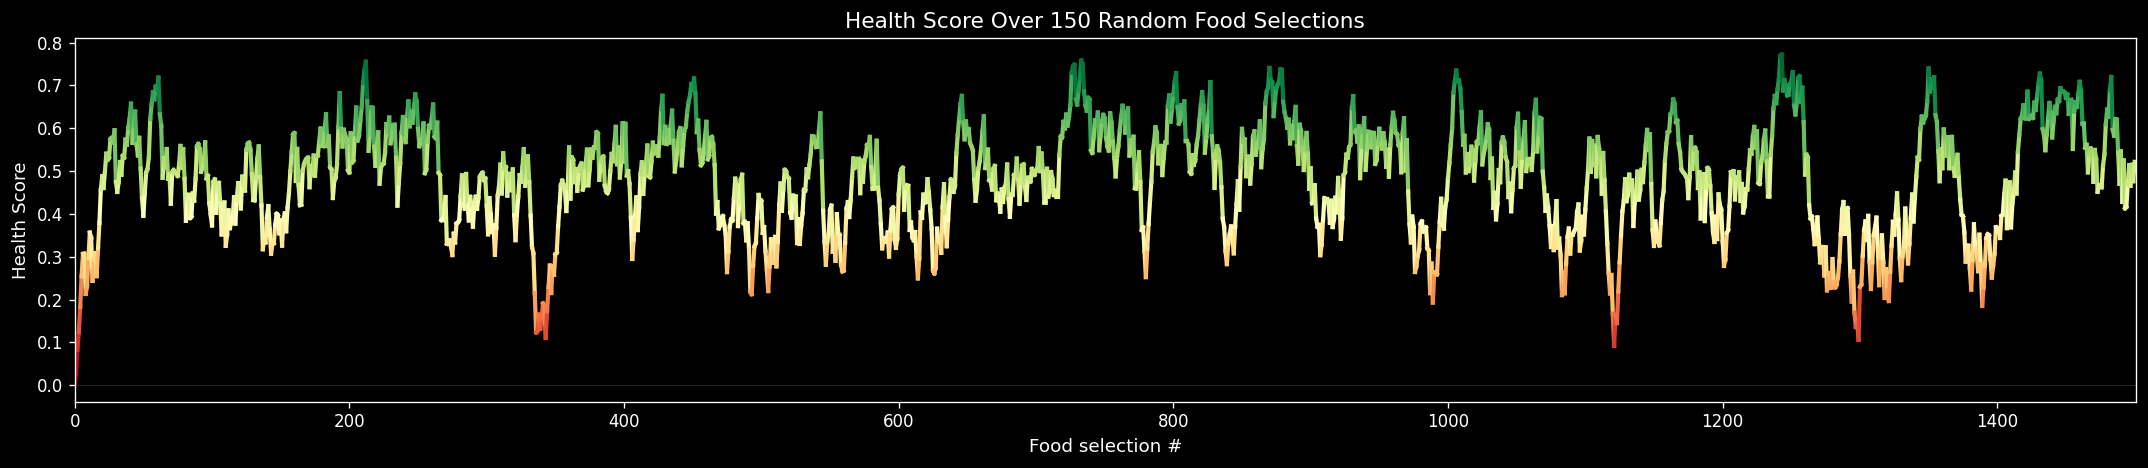

In [16]:
fig, ax = plt.subplots(figsize=(18, 4))
colors = plt.cm.RdYlGn(np.linspace(0, 1, 256))
health_norm = (health_arr - health_arr.min()) / (health_arr.max() - health_arr.min() + 1e-10)

for i in range(len(health_arr) - 1):
    c = plt.cm.RdYlGn(health_norm[i])
    ax.plot([i, i+1], [health_arr[i], health_arr[i+1]], color=c, linewidth=2.5)

ax.axhline(0, color='white', linewidth=0.3, alpha=0.3)
ax.set_xlabel('Food selection #', fontsize=11)
ax.set_ylabel('Health Score', fontsize=11)
ax.set_title('Health Score Over 150 Random Food Selections', fontsize=13)
ax.set_xlim(0, len(health_arr))
plt.tight_layout()
plt.show()


---
## 8. Cluster Analysis + Centroid Visualization

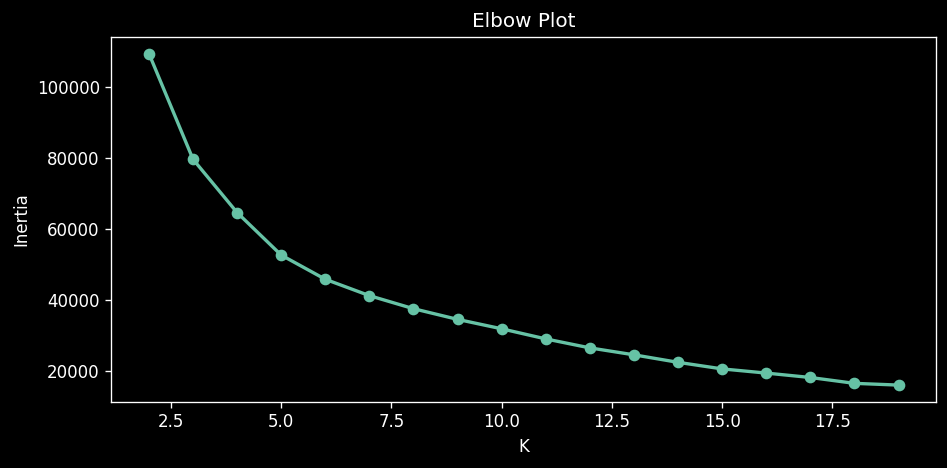

In [17]:
inertias = []
K_range = range(2, 20)
for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(profiles_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(K_range), inertias, 'o-', color='#66C2A5', linewidth=2)
ax.set_xlabel('K'); ax.set_ylabel('Inertia'); ax.set_title('Elbow Plot')
plt.tight_layout()
plt.show()

In [18]:
K = 12
km = KMeans(n_clusters=K, n_init=10, random_state=42)
cluster_labels = km.fit_predict(profiles_scaled)
plot_df['cluster'] = cluster_labels.astype(str)

centroids_scaled = km.cluster_centers_
centroids_3d = pca3.transform(centroids_scaled)
centroids_original = scaler.inverse_transform(centroids_scaled)

centroid_health = []
for ci in range(K):
    mask = cluster_labels == ci
    avg_health = health_scores_all[mask].mean()
    centroid_health.append(avg_health)

print(f'Cluster centroids (K={K}):')
for ci in range(K):
    n_members = (cluster_labels == ci).sum()
    top_diets = pd.Series([base_labels[j] for j in range(len(base_labels)) if cluster_labels[j] == ci]).value_counts().head(3)
    print(f'  Cluster {ci}: {n_members} members, health={centroid_health[ci]:.3f}, top diets: {dict(top_diets)}')

Cluster centroids (K=12):
  Cluster 0: 179 members, health=0.187, top diets: {'Chinese urban': np.int64(48), 'French': np.int64(46), 'Balanced': np.int64(37)}
  Cluster 1: 170 members, health=-0.421, top diets: {'US fast food': np.int64(50), 'Western processed': np.int64(49), 'Junk food': np.int64(48)}
  Cluster 2: 170 members, health=0.775, top diets: {'Raw vegan': np.int64(47), 'Pescatarian': np.int64(47), 'Mediterranean': np.int64(44)}
  Cluster 3: 47 members, health=-0.293, top diets: {'British pub': np.int64(45), 'Keto': np.int64(1), 'Junk food': np.int64(1)}
  Cluster 4: 296 members, health=0.692, top diets: {'South Indian': np.int64(50), 'Ethiopian': np.int64(50), 'High fiber': np.int64(48)}
  Cluster 5: 64 members, health=0.519, top diets: {'Dairy-heavy': np.int64(53), 'Middle Eastern': np.int64(2), 'Brazilian': np.int64(2)}
  Cluster 6: 64 members, health=0.198, top diets: {'Keto': np.int64(48), 'South Indian': np.int64(2), 'French': np.int64(2)}
  Cluster 7: 60 members, healt

In [19]:
fig = px.scatter_3d(
    plot_df, x='PC1', y='PC2', z='PC3', color='cluster',
    hover_name='label', opacity=0.5,
    title=f'K-Means Clusters (K={K})',
    template=PLOTLY_DARK, width=950, height=750,
    color_discrete_sequence=px.colors.qualitative.Set3,
)
fig.update_traces(marker=dict(size=3))

for ci in range(K):
    fig.add_trace(go.Scatter3d(
        x=[centroids_3d[ci, 0]], y=[centroids_3d[ci, 1]], z=[centroids_3d[ci, 2]],
        mode='markers+text', text=[f'C{ci}'], textposition='top center',
        marker=dict(size=14, color='white', symbol='diamond', line=dict(width=2, color=px.colors.qualitative.Set3[ci])),
        showlegend=False, hovertext=f'Centroid {ci}: health={centroid_health[ci]:.3f}',
    ))
fig.show()

---
## 9. Export Artifacts

In [20]:
food_profiles_df.to_csv(OUT_DIR / 'food_species_profiles.csv')
health_direction.to_csv(OUT_DIR / 'health_direction_vector.csv', header=['health_weight'])
importance.to_csv(OUT_DIR / 'species_importance.csv')
pd.Series(important_species, name='species').to_csv(OUT_DIR / 'important_species_list.csv', index=False)
weight_matrix.to_csv(OUT_DIR / 'food_category_weights.csv')

centroid_df = pd.DataFrame(centroids_original, columns=important_species)
centroid_df['health_score'] = centroid_health
centroid_df.index.name = 'cluster'
centroid_df.to_csv(OUT_DIR / 'cluster_centroids.csv')

print(f'Exported to {OUT_DIR.resolve()}:')
for f in sorted(OUT_DIR.glob('*.csv')):
    print(f'  {f.name} ({f.stat().st_size:,} bytes)')

Exported to /Users/ryanmillett/86BB/analysis/outputs:
  cluster_centroids.csv (37,715 bytes)
  food_category_weights.csv (8,532 bytes)
  food_species_profiles.csv (257,402 bytes)
  health_direction_vector.csv (5,857 bytes)
  important_species_list.csv (3,199 bytes)
  predict1_food_species_correlations.csv (73,065 bytes)
  predict1_food_species_qvalues.csv (67,672 bytes)
  predict1_significant_food_species.csv (31,748 bytes)
  species_importance.csv (27,865 bytes)
